# Computational Carpentry Project

Team members :
- Gregorio Adriano Rolli 
- Bogdan Filipchuk
- Yunhee Choi
- Artem Hrynov

## Part A — Data structures and functions

### 1. Load the periodic table


In [22]:
import pandas as pd

periodic_table = pd.read_csv("periodic_table.csv")
periodic_table.head()


,AtomicNumber,Symbol,Name,AtomicMass,CPKHexColor,ElectronConfiguration,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,OxidationStates,StandardState,MeltingPoint,BoilingPoint,Density,GroupBlock,YearDiscovered
0,1,H,Hydrogen,1.008000,FFFFFF,1s1,2.20,120.0,13.598,0.754,"+1, -1",Gas,13.81,20.28,0.000090,Nonmetal,1766
1,2,He,Helium,4.002600,D9FFFF,1s2,NaN,140.0,24.587,NaN,0,Gas,0.95,4.22,0.000179,Noble gas,1868
2,3,Li,Lithium,7.000000,CC80FF,[He]2s1,0.98,182.0,5.392,0.618,+1,Solid,453.65,1615.00,0.534000,Alkali metal,1817
3,4,Be,Beryllium,9.012183,C2FF00,[He]2s2,1.57,153.0,9.323,NaN,+2,Solid,1560.00,2744.00,1.850000,Alkaline earth metal,1798
4,5,B,Boron,10.810000,FFB5B5,[He]2s2 2p1,2.04,192.0,8.298,0.277,+3,Solid,2348.00,4273.00,2.370000,Metalloid,1808


### 2. Dictionary

`.set_index()` replaces integer indexes by the `Symbol`. The key `"Symbol"` associates each symbol with its value `"AtomicMass"`; `to_dict()` converts that mapping into a Python dictionary.


In [23]:
atomic_masses = periodic_table.set_index("Symbol")["AtomicMass"].to_dict()

atomic_masses


{'H': 1.008,
 'He': 4.0026,
 'Li': 7.0,
 'Be': 9.012183,
 'B': 10.81,
 'C': 12.011,
 'N': 14.007,
 'O': 15.999,
 'F': 18.99840316,
 'Ne': 20.18,
 'Na': 22.9897693,
 'Mg': 24.305,
 'Al': 26.981538,
 'Si': 28.085,
 'P': 30.973762,
 'S': 32.07,
 'Cl': 35.45,
 'Ar': 39.9,
 'K': 39.0983,
 'Ca': 40.08,
 'Sc': 44.95591,
 'Ti': 47.867,
 'V': 50.9415,
 'Cr': 51.996,
 'Mn': 54.93804,
 'Fe': 55.84,
 'Co': 58.93319,
 'Ni': 58.693,
 'Cu': 63.55,
 'Zn': 65.4,
 'Ga': 69.723,
 'Ge': 72.63,
 'As': 74.92159,
 'Se': 78.97,
 'Br': 79.9,
 'Kr': 83.8,
 'Rb': 85.468,
 'Sr': 87.62,
 'Y': 88.90584,
 'Zr': 91.22,
 'Nb': 92.90637,
 'Mo': 95.95,
 'Tc': 96.90636,
 'Ru': 101.1,
 'Rh': 102.9055,
 'Pd': 106.42,
 'Ag': 107.868,
 'Cd': 112.41,
 'In': 114.818,
 'Sn': 118.71,
 'Sb': 121.76,
 'Te': 127.6,
 'I': 126.9045,
 'Xe': 131.29,
 'Cs': 132.905452,
 'Ba': 137.33,
 'La': 138.9055,
 'Ce': 140.116,
 'Pr': 140.90766,
 'Nd': 144.24,
 'Pm': 144.91276,
 'Sm': 150.4,
 'Eu': 151.964,
 'Gd': 157.2,
 'Tb': 158.92535,
 'Dy': 16

### 3. Molecular mass formula

Read the formula from left to right. Each element symbol begins with an uppercase letter and can include a lowercase letter. The digits following it give the number of atoms. Without digits, the count is 1. Multiply each count by the atomic mass from `atomic_masses` and add the contributions. Using `while` loops instead of `for in` give more control over each step.


In [24]:
def molecular_mass(chemical_formula: str) -> float:
    """Returns the molecular mass of a chemical based on its formula"""

    total_mass = 0.0
    i = 0

    while i < len(chemical_formula):
        if chemical_formula[i] not in "ABCDEFGHIJKLMNOPQRSTUVWXYZ": #reads the symbol, uppecase then lowercase
            raise ValueError(f"Expected an uppercase element symbol at position {i + 1}.") #the first letter is always uppercase ; i + 1 makes it more human readable
        symbol = chemical_formula[i]
        i += 1
        if i < len(chemical_formula) and chemical_formula[i] in "abcdefghijklmnopqrstuvwxyz": #lowercase if two-letter symbol
            symbol += chemical_formula[i] #now symbol contains the str of one atom
            i += 1

        if symbol not in atomic_masses:
            raise ValueError(f"Unknown element: {symbol}")

        count_start = i #initiates the count of the digits, to handle pluridigit counts
        while i < len(chemical_formula) and chemical_formula[i] in "0123456789":
            i += 1
        count_text = chemical_formula[count_start:i] #extracts the number as a str
        count = int(count_text) if count_text else 1 #converts to int

        total_mass += atomic_masses[symbol] * count #adds the mass of one passage of the loop (i.e. one atomic symbol times its number)

    return total_mass


In [25]:
#examples
for formula in ["H2O", "C6H12O6", "NaCl"]:
    print(f"{formula}: {molecular_mass(formula)}")


H2O: 18.015
C6H12O6: 180.156
NaCl: 58.4397693


### 4. Handle parentheses using recursion

When `parse_group` encounters `(`, it calls itself to calculate the mass inside the parentheses. That call returns at the matching `)`, then we multiply the group mass by the following count.

Each call returns both its mass and the next unread position, so the outer call knows where to continue.


In [26]:
def molecular_mass(chemical_formula: str)-> float:
    """Returns the molecular mass of a chemical based on its formula, including groups in parentheses."""

    def read_count(i) -> tuple[int, int]: #does the same thing as point 3 but inside a function for either a group or a symbol
        """Read an optional positive integer and return the next position."""
        start = i
        while i < len(chemical_formula) and chemical_formula[i] in "0123456789":
            i += 1
        count = int(chemical_formula[start:i]) if i > start else 1
        return count, i

    def parse_group(i) -> tuple[float, int]:
        total_mass = 0.0

        while i < len(chemical_formula):
            character = chemical_formula[i]

            if character == ")":
                return total_mass, i + 1 #i + 1 makes it continue after the parenthesis

            if character == "(":
                term_mass, i = parse_group(i + 1) #recursively calls the parse_group function
            else:
                if character not in "ABCDEFGHIJKLMNOPQRSTUVWXYZ":
                    raise ValueError(f"Expected an uppercase element symbol at position {i + 1}.")
                symbol = character
                i += 1
                if i < len(chemical_formula) and chemical_formula[i] in "abcdefghijklmnopqrstuvwxyz":
                    symbol += chemical_formula[i]
                    i += 1
                if symbol not in atomic_masses:
                    raise ValueError(f"Unknown element: {symbol}")
                term_mass = atomic_masses[symbol]

            count, i = read_count(i)
            total_mass += term_mass * count

        return total_mass, i

    total_mass= parse_group(0)[0] #selects only the mass from the tuple
    return total_mass


In [27]:
#examples
for formula in ["Ca(OH)2", "Al2(SO4)3", "(NH4)2SO4", "K4(ON(SO3)2)2"]:
    print(f"{formula}: {molecular_mass(formula)} u")


Ca(OH)2: 74.094 u
Al2(SO4)3: 342.161076 u
(NH4)2SO4: 132.144 u
K4(ON(SO3)2)2: 536.6732000000001 u


### 5. Handle hydration water

Split the formula at each dot (`.`). A leading number multiplies the entire component after it.


In [28]:
def molecular_mass(chemical_formula: str) -> float:
    """Return molecular mass in u, including parentheses and hydration water."""

    #reused the point 4 algorithm to calculate each components mass
    def component_mass(chemical_formula: str) -> float:
        """Return molecular mass in u, including groups in parentheses."""

        def read_count(i) -> tuple[int, int]: #does the same thing as point 3 but inside a function for either a group or a symbol
            """Read an optional positive integer and return the next position."""
            start = i
            while i < len(chemical_formula) and chemical_formula[i] in "0123456789":
                i += 1
            count = int(chemical_formula[start:i]) if i > start else 1
            return count, i

        def parse_group(i) -> tuple[float, int]:
            total_mass = 0.0

            while i < len(chemical_formula):
                character = chemical_formula[i]

                if character == ")":
                    return total_mass, i + 1 #i + 1 makes it continue after the parenthesis

                if character == "(":
                    term_mass, i = parse_group(i + 1) #recursively calls the parse_group function
                else:
                    if character not in "ABCDEFGHIJKLMNOPQRSTUVWXYZ":
                        raise ValueError(f"Expected an uppercase element symbol at position {i + 1}.")
                    symbol = character
                    i += 1
                    if i < len(chemical_formula) and chemical_formula[i] in "abcdefghijklmnopqrstuvwxyz":
                        symbol += chemical_formula[i]
                        i += 1
                    if symbol not in atomic_masses:
                        raise ValueError(f"Unknown element: {symbol}")
                    term_mass = atomic_masses[symbol]

                count, i = read_count(i)
                total_mass += term_mass * count

            return total_mass, i

        total_mass= parse_group(0)[0] #selects only the mass from the tuple
        return total_mass        

    total_mass = 0.0
    components = chemical_formula.split(".") #each component separated by a "." is added to a list of str
    for component in components:
        i = 0
        while i < len(component) and component[i] in "0123456789": #assures pluridigit coefficients are properly counted
            i += 1
        coefficient = int(component[:i]) if i else 1 #extracts the coefficient form the component
        formula = component[i:] #extracts the formula from the component

        total_mass += coefficient * component_mass(formula)

    return total_mass


In [29]:
#examples
for formula in ["CuSO4.5H2O", "Na2CO3.10H2O", "Al2(SO4)3.18H2O"]:
    print(f"{formula}: {molecular_mass(formula)} u")


CuSO4.5H2O: 249.69100000000003 u
Na2CO3.10H2O: 286.13753859999997 u
Al2(SO4)3.18H2O: 666.431076 u


## Part B - Stoichiometry and reaction balancing 

1. **Reaction Balancer Function**




First we collect the element symbols


In [30]:
import numpy as np
from fractions import Fraction
from math import gcd


def parse_elements(compoundlist:list[str])->set[str]:
    """
    Returns a set of elements present in the current list of atoms 
    """
    elements = set()
    for reactant in compoundlist:
            for index, character in enumerate(reactant):
                if character.isupper():
                    element = character
                    if index+1 < len(reactant) and reactant[index+1].islower():  ### To account for two symbol elements
                        element+=reactant[index+1]
                    elements.add(element)
    return elements

def read_number(atom:str, index:int) -> tuple[int,int]:
    """
    Reads the digits starting at index untill the next non-digit. Returns (number, index just after them), no digits meaning 1.
    """
    digits = ""
    while index < len(atom) and atom[index].isdigit():
        digits += atom[index]
        index += 1
    return int(digits) if digits else 1, index




For simple formulas, we count how many times each element appears. We also check the next letter so that, for example, `C` is not accidentally counted inside `Cl`.


In [31]:
def numberofatoms_no_nesting(atom:str) -> dict[str,int]:
    """
    Returns a dict with atoms as keys and number of times this atom occurs in the molecule as value
    """
    mydict:dict[str,int]= {}
    elements = parse_elements([atom])
    for element in elements:
        counter:int = 0
        for index, character in enumerate(atom):

            if atom[index:index+len(element)] == element:

                digit_index = index + len(element)                                                                                          # start looking for numbers right after the element's letters
                if len(element) == 1 and digit_index < len(atom) and atom[digit_index].islower():                                           #prevents 1 character elements misfiring when they share the same letter with a 2 letter element like Cl (good thing i noticed that, tough stuff)
                    continue
                digits = ""                                                                                                                 #Starts collecting digits into a string, needs to be converted to int later ?
                while digit_index < len(atom) and atom[digit_index].isdigit():
                    digits += atom[digit_index]                                                                                             # keep grabbing characters as long as they're digits
                    digit_index += 1

                counter += int(digits) if digits else 1                                                                                     # no digits found = implicit count of 1

        mydict[element] = counter
    return mydict



For nested formulas (which are not in the scope of the exrcise) a small AI snippet

In [32]:
def numberofatoms_with_nesting(atom:str) -> dict[str,int]:
    """
    Returns a dict with atoms as keys and number of times this atom occurs in the molecule as value.
    Parentheses and brackets are handled by keeping one dict per nesting level on a stack: opening a
    group pushes a fresh dict, closing it pops that dict and merges it into the level below, each
    count multiplied by the group's subscript.
    """
    stack:list[dict[str,int]] = [{}]
    index:int = 0

    while index < len(atom):
        character = atom[index]

        if character == "(" or character == "[":
            stack.append({})
            index += 1

        elif character == ")" or character == "]":
            group = stack.pop()
            multiplier, index = read_number(atom, index + 1)                              #Multiplies the 
            for element, count in group.items():
                stack[-1][element] = stack[-1].get(element, 0) + count * multiplier

        elif character.isupper():
            element = character
            index += 1
            if index < len(atom) and atom[index].islower():                 ### To account for two symbol elements
                element += atom[index]
                index += 1
            count, index = read_number(atom, index)
            stack[-1][element] = stack[-1].get(element, 0) + count

        else:
            index += 1                                                      # anything else just gets skipped

    return stack[0]




Now we balance everything


In [33]:
def balance_reaction(reactants:list[str], products:list[str])->list[str]:  
    """Takes in reactants and products as a list of strings and returns a list of stoechiometric coefficients corresponding to them"""
    numberofatoms = numberofatoms_with_nesting if nesting else numberofatoms_no_nesting
    #Staging the matrix                                                                                                            
    elements = list[str](parse_elements(reactants) | parse_elements(products))                                                          #Converting the elemets set to list since we will iterate over them later 
    rows:int = len(elements)                                                                                                            #will represent elements in the matrix
    columns:int = len(reactants)+len(products)                                                                                          #represent stoechiometric coefficients in the matrix
    my_matrix = np.zeros((rows,columns))
    compounds = reactants + products

    #Forming the matrix to solve
    for row in range(rows):
        for column in range(columns):
            if column<len(reactants):
                my_matrix[row, column] = numberofatoms(compounds[column]).get(elements[row], 0)
            else:
                my_matrix[row, column] = -numberofatoms(compounds[column]).get(elements[row], 0)
    stoechiometric_coefficients:list[int] = solve_matrix(my_matrix)

    #Debug, displays nicely how the matrix to solve with SVD was formed
    if debug:
        
        print("Rows and columns represent:\n", "   ",*reactants,"->", *products)
        print(*elements, sep="\n")
        print(my_matrix)

    return stoechiometric_coefficients




We use SVD method to find a nonzero vector of coefficients that makes `matrix @ x = 0`. Then we approximate the values as fractions and use a common denominator to turn them into whole numbers.


In [34]:
def solve_matrix(matrix:np.ndarray) -> list[int]:
    """
    Takes the m x n matrix built by balance_reaction and returns the smallest vector of
    whole numbers x such that matrix @ x = 0.

    The columns of V (from the SVD matrix = U @ S @ V.T) that pair with a zero singular
    value span the null space, so the last one of them is a valid solution. It comes out
    as floats, so it gets rescaled into the smallest equivalent integers.
    """
    U, singular_values, Vt = np.linalg.svd(matrix)

    tolerance = max(matrix.shape) * np.finfo(float).eps * singular_values[0]                     # a singular value is never exactly 0 in floating point
    rank:int = int(np.sum(singular_values > tolerance))
    if rank == matrix.shape[1]:
        raise ValueError("Only the trivial all-zero solution exists, the reaction cannot be balanced")

    solution = Vt[-1]                                                                            # last row of V.T = last column of V = a null space vector
    if solution.sum() < 0:      # Sometimes SVD yeilds negative vectors as a result, this accounts for it
        solution = -solution

    #Turning the floats into the smallest possible whole numbers
    solution = solution / np.min(np.abs(solution[np.abs(solution) > 1e-10]))                     # smallest non zero entry becomes 1
    fractions = [Fraction(value).limit_denominator(1000) for value in solution]
    common_denominator:int = 1
    for fraction in fractions:
        common_denominator = common_denominator * fraction.denominator // gcd(common_denominator, fraction.denominator)

    return [int(fraction * common_denominator) for fraction in fractions]




Let's try balancing some example reactions: we will examine if the script can correctly balance glucose burning, the Haber-Bosch process and a complex redox reaction of Potassium Permanganate with HCl. 

Here the `nesting = False` parameter makes the non-nesting function run, which was demanded in the exercise. The `debug` parameter shows how exactly the coefficient matrix is constructed for the SVD treatment. In the next cell the more advanced function will be examined.


In [35]:
# Tests
debug = False
nesting = False

Glucose_reactants: list = ["C6H12O6", "O2"]
Glucose_products:  list = ["CO2", "H2O"]
print("Balancing glucose burning reaction:\n",balance_reaction(Glucose_reactants,Glucose_products))


Haber_reactants: list = ["N2", "H2"]
Haber_products:  list = ["NH3"]
print("Balancing Haber-Bosch process reaction:\n", balance_reaction(Haber_reactants,Haber_products))


Permanganate_reactants: list = ["KMnO4", "HCl"]
Permanganate_products:  list = ["KCl", "MnCl2", "H2O", "Cl2"]
print("Balancing permanganate with HCl reaction:\n",balance_reaction(Permanganate_reactants, Permanganate_products))



Balancing glucose burning reaction:
 [1, 6, 6, 6]
Balancing Haber-Bosch process reaction:
 [1, 3, 2]
Balancing permanganate with HCl reaction:
 [2, 16, 2, 2, 8, 5]


Now, by changing the nesting parameter we test wether the nested function works properly:

In [36]:
debug = False
nesting = True
Phosphate_reactants: list = ["Ca(OH)2", "H3PO4"]
Phosphate_products:  list = ["Ca3(PO4)2", "H2O"]

nesting = True
print("Balancing calcium hydroxide with phosphoric acid using the nested function:")
print(balance_reaction(Phosphate_reactants, Phosphate_products))

#Now trying the same reaction with the unnested

nesting = False
print("Balancing calcium hydroxide with phosphoric acid using the unnested function:")
print(balance_reaction(Phosphate_reactants, Phosphate_products))


Balancing calcium hydroxide with phosphoric acid using the nested function:
[3, 2, 1, 6]
Balancing calcium hydroxide with phosphoric acid using the unnested function:
[3, 1, 1, 3]


The result given by the unnested function is wrong: the unnested function ignores the 2 after (OH) and after (PO4). It reads Ca(OH)₂ as CaOH and Ca₃(PO₄)₂ as Ca₃PO₄. Those wrong formulas can still be balanced, so the SVD solver finds a non-zero answer. The error can be confirmed by performing the mass balance, which will be done in the next section.

2. **Mass Conservation Check**


Finally, we use `zip` to pair each compound with its coefficient and reuse `molecular_mass` from Part A. We multiply each mass by its coefficient and add up each side.

In [37]:
def mass_conservation_check(substrate_dictionary:dict[str,float], product_dictionary:dict[str,int])->bool:
    """
    This function takes dictionaries containing molecules and their corresponding stoechiometric coefficients as input, and returns True/False depending on whether the reaction is mass balanced.
    """
    substrate_mass_sum:float = 0.0
    product_mass_sum:float = 0.0
    for substrate in substrate_dictionary.keys():
        substrate_mass_sum+=substrate_dictionary.get(substrate)*molecular_mass(substrate)
    for product in product_dictionary.keys():
            product_mass_sum+=product_dictionary.get(product)*molecular_mass(product)
    #print(substrate_mass_sum,product_mass_sum)
    if abs(product_mass_sum - substrate_mass_sum) < 1e-6:
         return True
    else: 
         return False
    

Now this function is tested on 3 reactions, one being the burning of glucose and two reactions which were balanced by the nested and unnested functions.

In [38]:
# Glucose burning reaction

test_reactants: list = ["C6H12O6", "O2"]
test_products:  list = ["CO2", "H2O"]
coefficients:list[float] = balance_reaction(test_reactants,test_products)
test_reactants_dict: dict[str, float] = dict(zip(test_reactants, coefficients[:len(test_reactants)]))
test_products_dict: dict[str, float] = dict(zip(test_products, coefficients[len(test_reactants):]))

result = mass_conservation_check(test_reactants_dict, test_products_dict)
print(result, "- the reaction is balanced" if result else "- the reaction is not balanced")

# Phosphate reaction balanced with the nested function
nesting = True
phosphate_nested_coefficients: list[int] = balance_reaction(Phosphate_reactants, Phosphate_products)
phosphate_nested_reactants_dict: dict[str, int] = dict(zip(Phosphate_reactants, phosphate_nested_coefficients[:len(Phosphate_reactants)]))
phosphate_nested_products_dict: dict[str, int] = dict(zip(Phosphate_products, phosphate_nested_coefficients[len(Phosphate_reactants):]))
result = mass_conservation_check(phosphate_nested_reactants_dict, phosphate_nested_products_dict)
print(result, "- the reaction is balanced" if result else "- the reaction is not balanced")

# Same reaction balanced with the unnested function
nesting = False
phosphate_unnested_coefficients: list[int] = balance_reaction(Phosphate_reactants, Phosphate_products)
phosphate_unnested_reactants_dict: dict[str, int] = dict(zip(Phosphate_reactants, phosphate_unnested_coefficients[:len(Phosphate_reactants)]))
phosphate_unnested_products_dict: dict[str, int] = dict(zip(Phosphate_products, phosphate_unnested_coefficients[len(Phosphate_reactants):]))
result = mass_conservation_check(phosphate_unnested_reactants_dict, phosphate_unnested_products_dict)
print(result, "- the reaction is balanced" if result else "- the reaction is not balanced")

True - the reaction is balanced
True - the reaction is balanced
False - the reaction is not balanced


## Part C — Simulation/Modeling

## Part 1 - Monte Carlo pi esimation





Let's play with the randomizer a bit

In [39]:
import numpy as np

In [40]:
import random

x = random.randint(1,10) # for an integer
x = random.uniform(5, 10) # if we want a random float between two fixed numbers
x = random.random() # if we want a random float [0,1[

random_points = []
for i in range(0, 10000):
    x_float = random.uniform(-1,1)
    y_float = random.uniform(-1,1)
    random_points.append([x_float,y_float])

#print(random_points)

It turns out that we can generate the numbers a bit faster with numpy, because it runs "at once" in low-level code, which is more optimised:


In [41]:
random_points = np.random.uniform(
    -1, 
    1, 
    size=(100_000_000, 2)
)

Let's save all the points that are inside a circle in a list

In [42]:
#points_inside = []
#for point in random_points:
 #   if np.linalg.norm(point) <= 1:
  #      points_inside.append(point)


#print(len(points_inside))

Turns out again that numpy can make it so much faster, by getting rid of the loops:

In [43]:
norms = np.linalg.norm(random_points, axis = 1)
points_inside = random_points[norms <= 1]
print(len(points_inside))
print(4*len(points_inside)/len(random_points))

78538134
3.14152536


The probability that a random point in the square lies inside the unit circle is

$$
P=\frac{A_{\text{circle}}}{A_{\text{square}}}
=\frac{\pi}{4}.
$$

Therefore,

$$
\pi \approx 4\frac{N_{\text{inside}}}{N}.
$$
That's exactly where the factor of 4 comes from in the code above


Now let's assemble everything together

In [44]:
def estimate_pi(N):
    random_points = np.random.uniform(-1, 1,size=(N, 2))

    norms = np.linalg.norm(random_points, axis = 1)
    points_inside = random_points[norms <= 1]
    approximation = 4*len(points_inside)/len(random_points)
    #print(f" The pi estimate is: {approximation}")
    return approximation

Now let's plot our pi approximation with growing N

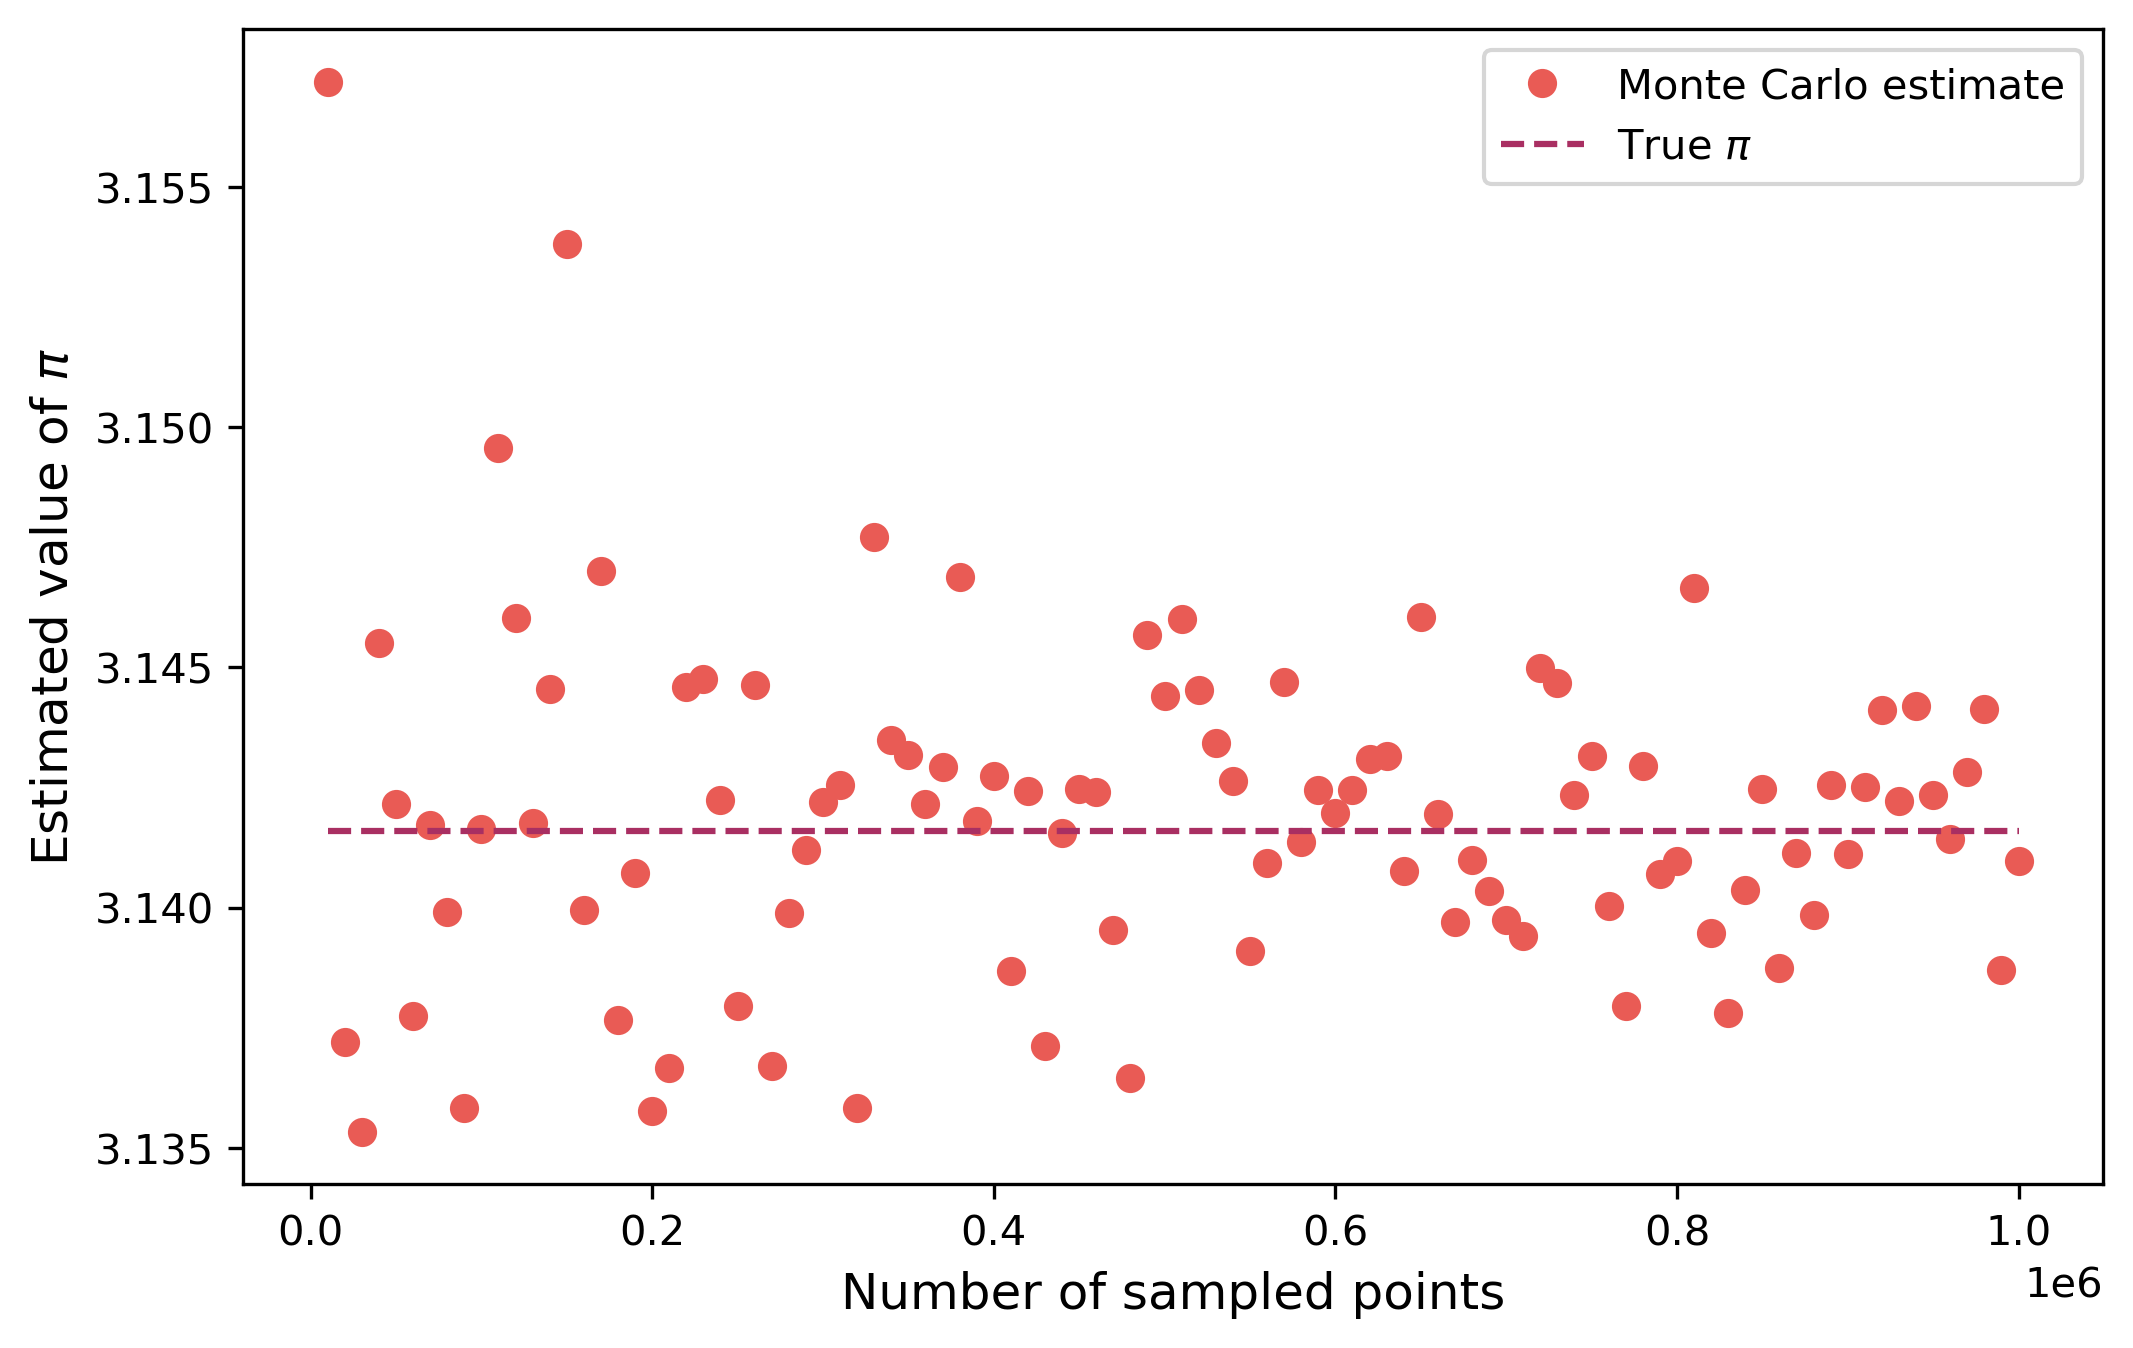

In [45]:
import matplotlib.pyplot as plt

Ns = []
approximations = []

for N in range (10_000, 1_000_001, 10_000): #change to smaller values because it is lowkey long
    approximation = estimate_pi(N)
    Ns.append(N)
    approximations.append(approximation)

plt.figure(figsize=(8, 5), dpi=300) #to have a nice quality

plt.plot(Ns, approximations, linestyle="", marker = "o", color="#E95B55", label="Monte Carlo estimate") # coral, because the default colors are ugly
plt.plot(Ns, [np.pi]*len(Ns), linestyle="--", color="#A92F62",label=r"True $\pi$") # dark magenta

plt.xlabel("Number of sampled points", fontsize=12)
plt.ylabel(r"Estimated value of $\pi$", fontsize=12)
plt.legend()
plt.show()

We also plot how far each estimate is from the real value of pi

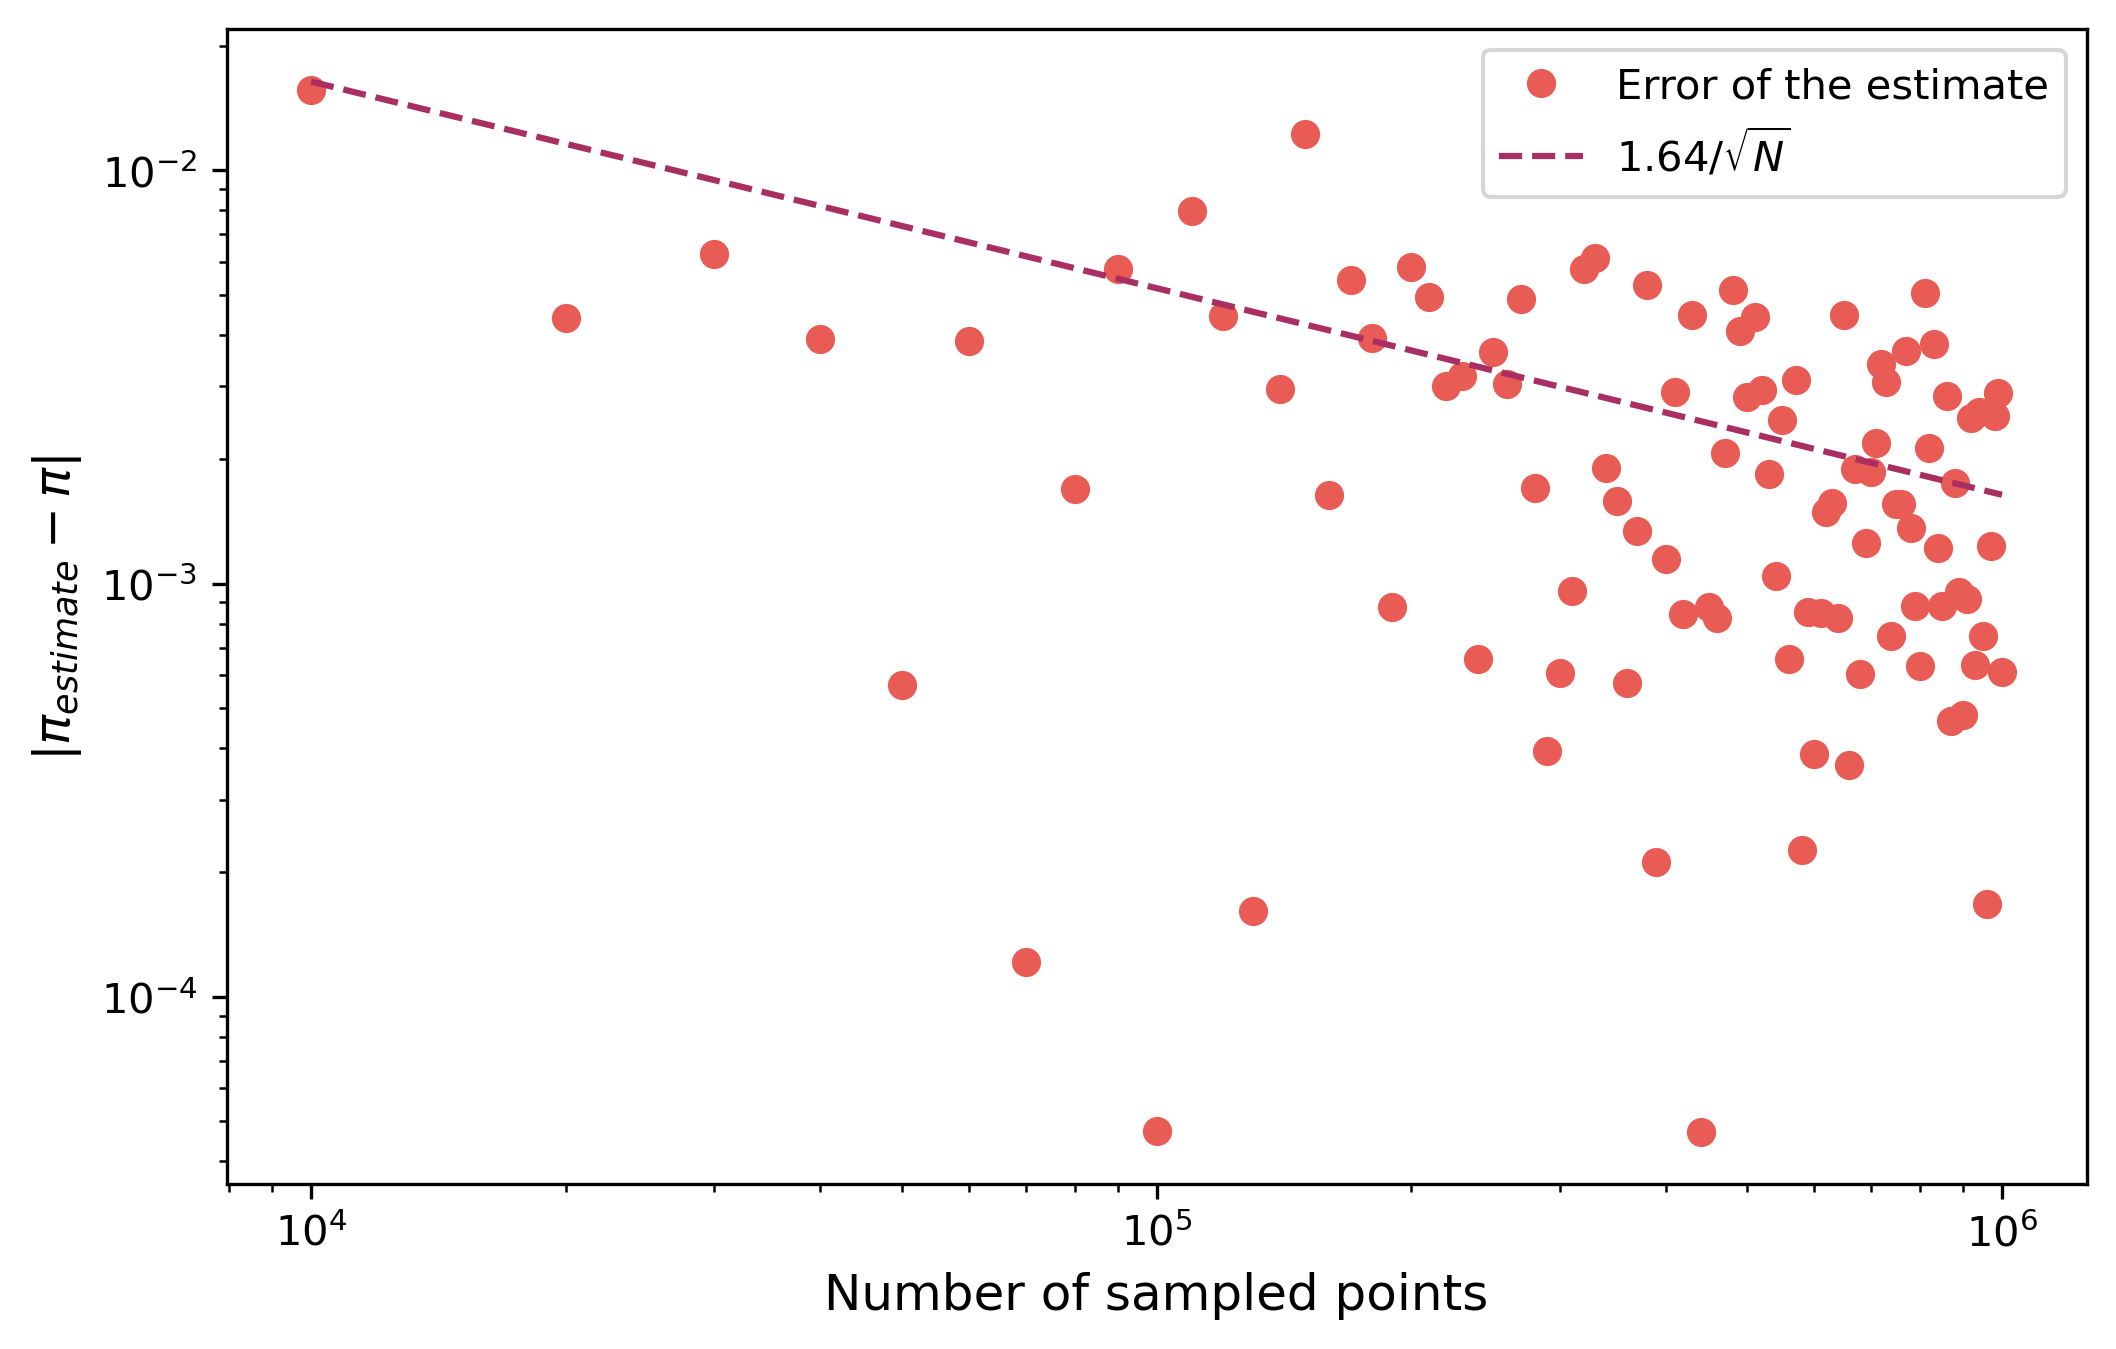

In [46]:
errors = np.abs(np.array(approximations) - np.pi)

plt.figure(figsize=(8, 5), dpi=300)

plt.loglog(Ns, errors, linestyle="", marker="o", color="#E95B55", label="Error of the estimate") # same colors as the plot above
plt.loglog(Ns, 1.64/np.sqrt(Ns), linestyle="--", color="#A92F62", label=r"$1.64/\sqrt{N}$")

plt.xlabel("Number of sampled points", fontsize=12)
plt.ylabel(r"$|\pi_{estimate} - \pi|$", fontsize=12)
plt.legend()
plt.show()

In the first plot the estimates are spread out for small $N$, and they stay closer to the dashed line as $N$ increases. The second plot shows how fast the error decreases. Each point is either inside the circle or not, with probability $p=\pi/4$, so the spread of our estimate should be about $4\sqrt{p(1-p)/N} \approx 1.64/\sqrt{N}$. Most of our errors are around or below this line, which agrees with this.

This means the error only decreases as $1/\sqrt{N}$, so to get one more correct digit we need 100 times more points. Even with $10^6$ points we only get about 3 correct digits of $\pi$. Monte Carlo is easy to implement, but it converges slowly.

## Part 2 - Chemistry inspired Monte Carlo


A bit confusing where to start, but let's give it a go by reusing our position randomizer from before

We simulate $M$ collisions in a box, using the same square from $-1$ to $1$ as before. Each collision gets a random position and a random energy between 0 and 100 from a uniform distribution (the units are arbitrary here). Then we count how many collisions have an energy at least equal to the threshold energy.

The positions do not change the result, because the energy does not depend on where the collision happens. We kept them in case we want to know where the reacting collisions took place.

In [47]:
random_collisions = np.random.uniform(-1, 1, size=(1_000_000, 2))
random_energies = np.random.uniform(0,100,size=1_000_000) #same principle here
#we also have to make sure that arrays have the same number of collisions
threshold_energy = 50
threshold = random_energies >= threshold_energy #choosing the energies above the threshold
above_threshold = random_collisions[threshold] #not neccessary per say, but added in case we want to have them 

print(len(above_threshold))
print(len(above_threshold)/len(random_collisions))


499302
0.499302


We assume that a collision leads to a reaction when

$$
E \geq E_{\text{threshold}}.
$$

We can estimate the reaction probability as

$$
P(\text{reaction})
\approx
\frac{N_{\text{above threshold}}}{M}.
$$

Now let's wrap it up into a nice function


In [48]:
def simulate_collisions(number_of_collisions, energy_min, energy_max, threshold_energy):
    """Simulates M collisions with uniform random energies and returns
    (number of collisions above the threshold, estimated reaction probability)."""
    random_collisions = np.random.uniform(-1, 1, size=(number_of_collisions, 2))
    random_energies = np.random.uniform(energy_min,energy_max,size=number_of_collisions)
    energy_above = random_energies >= threshold_energy
    above_threshold = random_collisions[energy_above]

    above = len(above_threshold)
    probability = len(above_threshold)/len(random_collisions)
    return above, probability

simulate_collisions(1_000_000, 0, 1000, 750)


(250187, 0.250187)

For a uniform distribution we can check the result by hand. The probability is the part of the energy range above the threshold, $P = \frac{E_{max}-E_{threshold}}{E_{max}-E_{min}}$. This gives 0.5 for the first run (threshold 50 between 0 and 100) and 0.25 for the function (threshold 750 between 0 and 1000). Both of our simulations are only about 0.001 away from these values, which is the size of error we expect for a million collisions, following the same $1/\sqrt{M}$ behaviour as for $\pi$.

The fraction we get is our estimate of the reaction probability: the share of collisions with enough energy to overcome the activation barrier. When the threshold is higher, fewer collisions react, which is the same idea as the Arrhenius factor $e^{-E_a/RT}$. In a real gas the energies follow a Boltzmann distribution instead of a uniform one, so only the few collisions in the high-energy tail lead to a reaction.

What we learned from Part C is that Monte Carlo turns a problem into counting. The answer is always a fraction of random trials, and its accuracy only improves as $1/\sqrt{N}$, so many points are needed. For that many points, NumPy is necessary, since Python loops are much slower.